In [4]:
%config InlineBackend.figure_format = 'retina'

In [5]:
from common import *

In [6]:
df = read_trace("1.csv")
df.head(n=20)

,type,timestamp_us,count,layer_idx,seq_len,token_idx
0,StartTracing,0,<NA>,<NA>,<NA>,<NA>
1,CheckpointBegin,978199,<NA>,<NA>,<NA>,<NA>
2,CheckpointMetadata,978372,<NA>,<NA>,<NA>,<NA>
3,CheckpointFilesOpen,978406,<NA>,<NA>,<NA>,<NA>
4,CheckpointHCacheWrite,978584,<NA>,<NA>,<NA>,<NA>
5,CheckpointKVCacheWrite,979045,<NA>,<NA>,<NA>,<NA>
6,CheckpointFlush,979049,<NA>,<NA>,<NA>,<NA>
7,CheckpointFsyncData,982098,<NA>,<NA>,<NA>,<NA>
8,CheckpointWatermark,983734,<NA>,<NA>,<NA>,<NA>
9,CheckpointComplete,983735,0,<NA>,<NA>,<NA>


In [7]:
# Match checkpoint end events with their corresponding begin events
ends = df[df['type'] == 'CheckpointComplete'][['timestamp_us', 'count']].copy()
begins = df[df['type'] == 'CheckpointBegin'][['timestamp_us']].copy()
begins.columns = ['begin_timestamp']

# Merge to find most recent begin before each end
checkpoint_df = pd.merge_asof(ends, begins, left_on='timestamp_us', right_on='begin_timestamp', direction='backward')
checkpoint_df = checkpoint_df.rename(columns={'timestamp_us': 'end_timestamp'})
checkpoint_df['duration_us'] = checkpoint_df['end_timestamp'] - checkpoint_df['begin_timestamp']
checkpoint_df['event_type'] = 'checkpoint'
checkpoint_df = checkpoint_df[['begin_timestamp', 'end_timestamp', 'duration_us', 'count', 'event_type']]
checkpoint_df

,begin_timestamp,end_timestamp,duration_us,count,event_type
0,978199,983735,5536,0,checkpoint
1,24017458,24028084,10626,64,checkpoint
2,24065735,24075612,9877,32,checkpoint
3,24113196,24122524,9328,32,checkpoint
4,24159711,24170167,10456,32,checkpoint
...,...,...,...,...,...
72,27322884,27334358,11474,32,checkpoint
73,27373855,27383164,9309,32,checkpoint
74,27422786,27432208,9422,32,checkpoint
75,27471899,27481241,9342,32,checkpoint


In [8]:
# Match layer complete events with their corresponding begin events
layer_ends = df[df['type'] == 'LayerComplete'][['timestamp_us', 'layer_idx', 'seq_len', 'token_idx']].copy()
layer_begins = df[df['type'] == 'LayerBegin'][['timestamp_us', 'layer_idx', 'seq_len', 'token_idx']].copy()
layer_begins.columns = ['begin_timestamp', 'layer_idx', 'seq_len', 'token_idx']

# Merge to find corresponding begin for each end (matching on layer_idx, seq_len, token_idx)
layer_df = pd.merge_asof(layer_ends, layer_begins, 
                         left_on='timestamp_us', right_on='begin_timestamp', 
                         by=['layer_idx', 'seq_len', 'token_idx'], direction='backward')
layer_df = layer_df.rename(columns={'timestamp_us': 'end_timestamp'})
layer_df['duration_us'] = layer_df['end_timestamp'] - layer_df['begin_timestamp']
layer_df['event_type'] = 'layer'
layer_df = layer_df[['begin_timestamp', 'end_timestamp', 'duration_us', 'layer_idx', 'seq_len', 'token_idx', 'event_type']]
layer_df

,begin_timestamp,end_timestamp,duration_us,layer_idx,seq_len,token_idx,event_type
0,23965219,24017355,52136,0,32,0,layer
1,24028109,24065662,37553,1,32,0,layer
2,24075631,24113078,37447,2,32,0,layer
3,24122541,24159617,37076,3,32,0,layer
4,24170188,24208306,38118,4,32,0,layer
...,...,...,...,...,...,...,...
69,27283344,27322779,39435,13,32,64,layer
70,27334382,27373771,39389,14,32,64,layer
71,27383187,27422672,39485,15,32,64,layer
72,27432225,27471786,39561,16,32,64,layer


In [9]:
# Merge checkpoint and layer dataframes, sort by end_timestamp
merged_df = pd.concat([checkpoint_df, layer_df], ignore_index=True).sort_values('end_timestamp').reset_index(drop=True)
merged_df['duration_ms'] = merged_df['duration_us'] / 1000
merged_df.head(n=30)

,begin_timestamp,end_timestamp,duration_us,count,event_type,layer_idx,seq_len,token_idx,duration_ms
0,978199,983735,5536,0,checkpoint,<NA>,<NA>,<NA>,5.536
1,23965219,24017355,52136,<NA>,layer,0,32,0,52.136
2,24017458,24028084,10626,64,checkpoint,<NA>,<NA>,<NA>,10.626
3,24028109,24065662,37553,<NA>,layer,1,32,0,37.553
4,24065735,24075612,9877,32,checkpoint,<NA>,<NA>,<NA>,9.877
5,24075631,24113078,37447,<NA>,layer,2,32,0,37.447
6,24113196,24122524,9328,32,checkpoint,<NA>,<NA>,<NA>,9.328
7,24122541,24159617,37076,<NA>,layer,3,32,0,37.076
8,24159711,24170167,10456,32,checkpoint,<NA>,<NA>,<NA>,10.456
9,24170188,24208306,38118,<NA>,layer,4,32,0,38.118


In [10]:
# Get all checkpoint events
checkpoint_events = df[df['type'].str.startswith('Checkpoint')].copy()
checkpoint_events = checkpoint_events.sort_values('timestamp_us').reset_index(drop=True)

# Find all checkpoint begin events
checkpoint_begins = checkpoint_events[checkpoint_events['type'] == 'CheckpointBegin'].copy()
checkpoint_begins['checkpoint_id'] = range(len(checkpoint_begins))

# Assign each checkpoint event to its corresponding checkpoint
# Use merge_asof to find the most recent CheckpointBegin before each event
checkpoint_events_with_id = pd.merge_asof(
    checkpoint_events,
    checkpoint_begins[['timestamp_us', 'checkpoint_id']].rename(columns={'timestamp_us': 'begin_timestamp'}),
    left_on='timestamp_us',
    right_on='begin_timestamp',
    direction='backward'
)

# Filter to only events that belong to a checkpoint (have a checkpoint_id)
checkpoint_events_with_id = checkpoint_events_with_id[checkpoint_events_with_id['checkpoint_id'].notna()].copy()
checkpoint_events_with_id['checkpoint_id'] = checkpoint_events_with_id['checkpoint_id'].astype(int)

# Get begin timestamps for each checkpoint
checkpoint_begin_times = checkpoint_begins.set_index('checkpoint_id')['timestamp_us'].to_dict()

# Determine the order of event types (based on first checkpoint's event order)
first_checkpoint_events = checkpoint_events_with_id[
    checkpoint_events_with_id['checkpoint_id'] == checkpoint_events_with_id['checkpoint_id'].min()
].sort_values('timestamp_us')
event_type_order = first_checkpoint_events['type'].tolist()

# Calculate time_to_begin and time_to_previous for each event
results = []
for checkpoint_id in sorted(checkpoint_events_with_id['checkpoint_id'].unique()):
    checkpoint_events_subset = checkpoint_events_with_id[
        checkpoint_events_with_id['checkpoint_id'] == checkpoint_id
    ].sort_values('timestamp_us').reset_index(drop=True)
    
    begin_timestamp = checkpoint_begin_times[checkpoint_id]
    
    row_data = {}
    
    prev_timestamp = begin_timestamp
    for idx, event in checkpoint_events_subset.iterrows():
        event_type = event['type']
        event_timestamp = event['timestamp_us']
        
        time_to_begin = event_timestamp - begin_timestamp
        time_to_previous = event_timestamp - prev_timestamp
        
        row_data[event_type] = (time_to_begin, time_to_previous)
        prev_timestamp = event_timestamp
    
    results.append(row_data)

# Create DataFrame from results
checkpoint_analysis_df = pd.DataFrame(results)

# Reorder columns to match event_type_order
existing_cols = [col for col in event_type_order if col in checkpoint_analysis_df.columns]
checkpoint_analysis_df = checkpoint_analysis_df[existing_cols]

# Display the table
checkpoint_analysis_df

,CheckpointBegin,CheckpointMetadata,CheckpointFilesOpen,CheckpointHCacheWrite,CheckpointKVCacheWrite,CheckpointFlush,CheckpointFsyncData,CheckpointWatermark,CheckpointComplete
0,"(0, 0)","(173, 173)","(207, 34)","(385, 178)","(846, 461)","(850, 4)","(3899, 3049)","(5535, 1636)","(5536, 1)"
1,"(0, 0)","(518, 518)","(559, 41)","(1049, 490)","(2291, 1242)","(2292, 1)","(8897, 6605)","(10625, 1728)","(10626, 1)"
2,"(0, 0)","(466, 466)","(501, 35)","(831, 330)","(2035, 1204)","(2035, 0)","(8295, 6260)","(9875, 1580)","(9877, 2)"
3,"(0, 0)","(352, 352)","(386, 34)","(688, 302)","(1864, 1176)","(1865, 1)","(7616, 5751)","(9327, 1711)","(9328, 1)"
4,"(0, 0)","(339, 339)","(371, 32)","(702, 331)","(1901, 1199)","(1902, 1)","(8854, 6952)","(10454, 1600)","(10456, 2)"
...,...,...,...,...,...,...,...,...,...
72,"(0, 0)","(379, 379)","(416, 37)","(733, 317)","(1825, 1092)","(1826, 1)","(9856, 8030)","(11473, 1617)","(11474, 1)"
73,"(0, 0)","(347, 347)","(379, 32)","(694, 315)","(1753, 1059)","(1753, 0)","(7569, 5816)","(9308, 1739)","(9309, 1)"
74,"(0, 0)","(376, 376)","(411, 35)","(729, 318)","(1801, 1072)","(1802, 1)","(7828, 6026)","(9421, 1593)","(9422, 1)"
75,"(0, 0)","(403, 403)","(437, 34)","(781, 344)","(1867, 1086)","(1869, 2)","(7653, 5784)","(9341, 1688)","(9342, 1)"


(<Figure size 500.093x309.075 with 1 Axes>, <Axes: >)

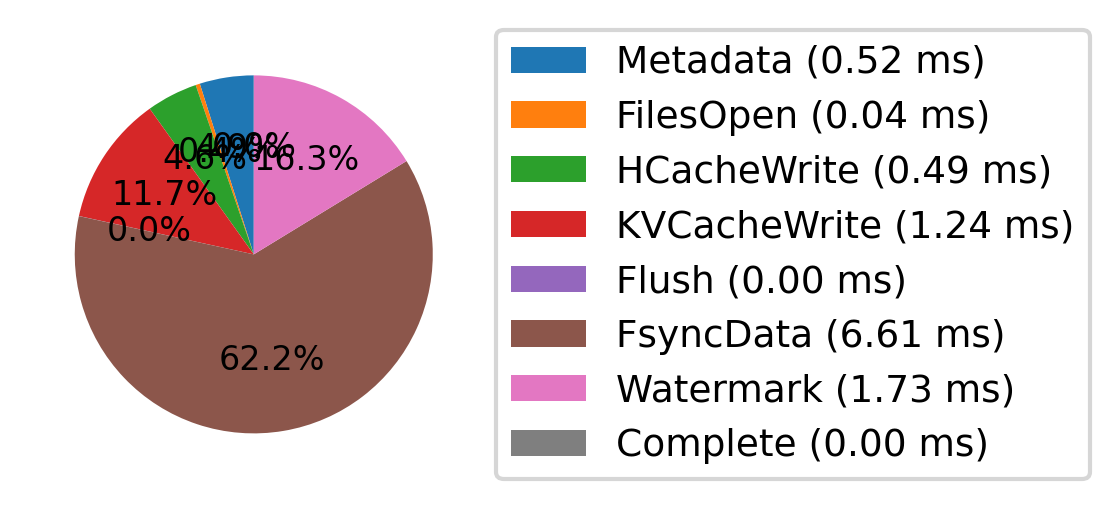

In [17]:
def plot_checkpoint_pie(row):
    """Plot a pie chart showing the cost breakdown of each component for a checkpoint."""
    components = []
    times = []
    
    for col, value in row.items():
        if pd.notna(value):
            _, time_to_previous = value
            component_name = col.replace('Checkpoint', '')
            if component_name != 'Begin' and time_to_previous > 0:
                components.append(component_name)
                times.append(time_to_previous)
    
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts, autotexts = ax.pie(
        times, 
        labels=None,  # No labels on pie slices
        autopct='%1.1f%%', 
        startangle=90,
        textprops={'fontsize': font_size - 1}
    )
    
    # Use legend instead of labels to avoid overlap
    ax.legend(wedges, [f'{c} ({t/1000:.2f} ms)' for c, t in zip(components, times)],
              loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=font_size)
    
    plt.tight_layout()
    return fig, ax

# Example: plot pie chart for first checkpoint
plot_checkpoint_pie(checkpoint_analysis_df.iloc[1])